# Polars Avanzado — Notebook Detallado con Gráficos y Dataset Real (Iris)
Versión paralela al notebook de Pandas, pero usando **Polars** para mostrar sintaxis y rendimiento modernos.

## 1. Carga del dataset real (Iris)

In [18]:
import polars as pl
from sklearn import datasets
import matplotlib.pyplot as plt

iris = datasets.load_iris(as_frame=True)
df = pl.from_pandas(iris.frame)
df.head()

sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
f64,f64,f64,f64,i64
5.1,3.5,1.4,0.2,0
4.9,3.0,1.4,0.2,0
4.7,3.2,1.3,0.2,0
4.6,3.1,1.5,0.2,0
5.0,3.6,1.4,0.2,0


### Explicación
Cargamos el dataset Iris desde `sklearn`, lo convertimos a Polars (`from_pandas`) para trabajar con expresiones eficientes. `df.head()` valida estructura inicial.


## 2. Estadísticas básicas y exploración

In [2]:
df.describe()

statistic,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
str,f64,f64,f64,f64,f64
"""count""",150.0,150.0,150.0,150.0,150.0
"""null_count""",0.0,0.0,0.0,0.0,0.0
"""mean""",5.843333,3.057333,3.758,1.199333,1.0
"""std""",0.828066,0.435866,1.765298,0.762238,0.819232
"""min""",4.3,2.0,1.0,0.1,0.0
"""25%""",5.1,2.8,1.6,0.3,0.0
"""50%""",5.8,3.0,4.4,1.3,1.0
"""75%""",6.4,3.3,5.1,1.8,2.0
"""max""",7.9,4.4,6.9,2.5,2.0


### Explicación
`df.describe()` en Polars genera estadísticas resumen (count, mean, std, min, max) para columnas numéricas, útil para exploración temprana.


In [3]:
df['target'].value_counts()

target,count
i64,u32
2,50
0,50
1,50


### Explicación
Conteo de valores de la columna `target` para verificar distribución de clases; Polars permite acceso directo con `col['target'].value_counts()`.


### Gráfico: Dispersión Sepal Length vs Sepal Width

Text(0.5, 1.0, 'Scatter Plot - Sepal Dimensions')

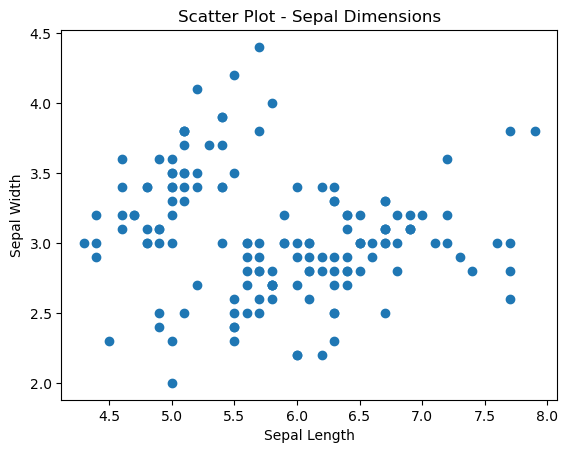

In [4]:
pdf = df.to_pandas()
plt.scatter(pdf['sepal length (cm)'], pdf['sepal width (cm)'])
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Scatter Plot - Sepal Dimensions')

### Explicación
Convertimos a pandas para usar `matplotlib` (Polars interoperable). Gráfico de dispersión para detectar correlación y distribución entre largo y ancho del sépalo.


## 3. GroupBy avanzado con agregaciones múltiples

In [6]:
df.group_by('target').agg([
    pl.col('sepal length (cm)').mean().alias('mean_sepal_len'),
    pl.col('sepal length (cm)').min().alias('min_sepal_len'),
    pl.col('sepal length (cm)').max().alias('max_sepal_len'),
    pl.col('petal length (cm)').std().alias('std_petal_len')
])

target,mean_sepal_len,min_sepal_len,max_sepal_len,std_petal_len
i64,f64,f64,f64,f64
1,5.936,4.9,7.0,0.469911
0,5.006,4.3,5.8,0.173664
2,6.588,4.9,7.9,0.551895


### Explicación
Agrupamos por `target` y aplicamos múltiples agregaciones usando expresiones: cada `pl.col(...).func().alias()` define una métrica clara y eficiente (lazy-friendly).


## 4. Visualización por grupos (vía conversión a pandas)

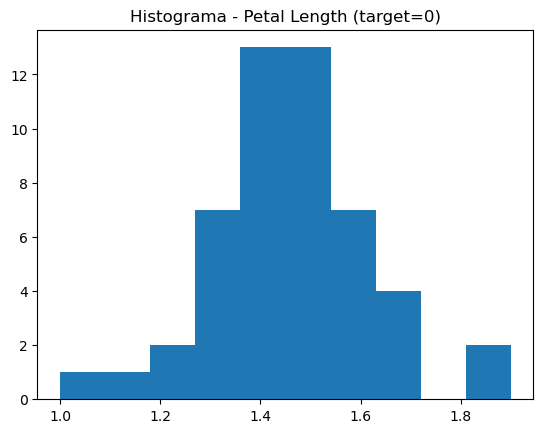

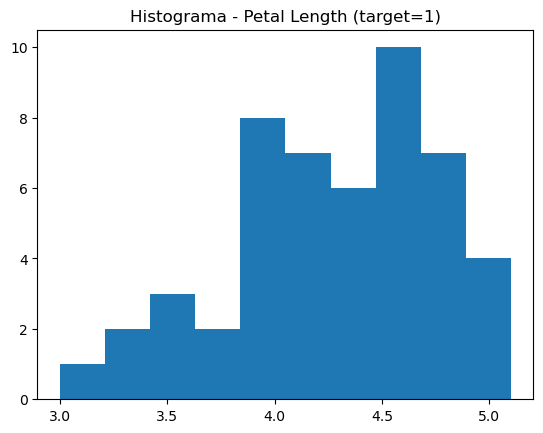

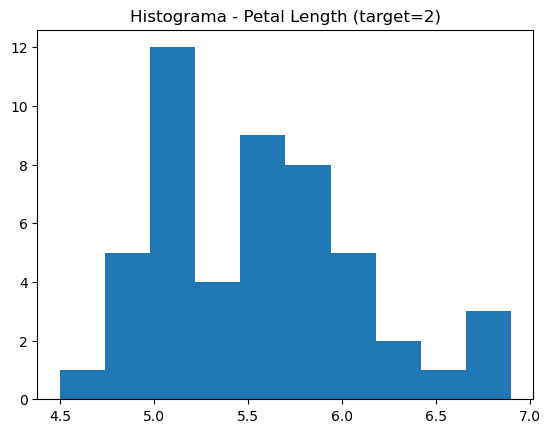

In [8]:
for label, g in pdf.groupby('target'):
    plt.figure()
    plt.hist(g['petal length (cm)'])
    plt.title(f'Histograma - Petal Length (target={label})')

### Explicación
Bucle de histogramas por clase tras conversión a pandas: permite comparar distribución de `petal length (cm)` entre especies. Cada figura aislada facilita análisis visual.


## 5. Columnas derivadas con expresiones Polars

In [9]:
df = df.with_columns([
    (pl.col('sepal length (cm)') / pl.col('sepal width (cm)')).alias('sepal_ratio')
])
df.head()

sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,sepal_ratio
f64,f64,f64,f64,i64,f64
5.1,3.5,1.4,0.2,0,1.457143
4.9,3.0,1.4,0.2,0,1.633333
4.7,3.2,1.3,0.2,0,1.46875
4.6,3.1,1.5,0.2,0,1.483871
5.0,3.6,1.4,0.2,0,1.388889


### Explicación
`with_columns` crea columna derivada `sepal_ratio` usando expresión vectorizada Polars (sin bucles) combinando largo/ancho del sépalo.


## 6. Join con dataset artificial

In [10]:
df_extra = pl.DataFrame({
    'target':[0,1,2],
    'species':['setosa','versicolor','virginica']
})

df_merged = df.join(df_extra, on='target')
df_merged.head()

sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,sepal_ratio,species
f64,f64,f64,f64,i64,f64,str
5.1,3.5,1.4,0.2,0,1.457143,"""setosa"""
4.9,3.0,1.4,0.2,0,1.633333,"""setosa"""
4.7,3.2,1.3,0.2,0,1.46875,"""setosa"""
4.6,3.1,1.5,0.2,0,1.483871,"""setosa"""
5.0,3.6,1.4,0.2,0,1.388889,"""setosa"""


### Explicación
`join` interno por `target` añade nombre de especie desde tabla auxiliar. Polars mantiene tipos y evita duplicados si claves son únicas.


## 7. Resampling temporal (simulado)

In [23]:
import polars as pl
from sklearn import datasets
import matplotlib.pyplot as plt

iris = datasets.load_iris(as_frame=True)
df = pl.from_pandas(iris.frame)
df.head()

df.height


150

In [24]:
import polars as pl
import pandas as pd
import numpy as np

# df: Polars DataFrame
rng = pd.date_range('2024-01-01', periods=df.height, freq='D')

df_time = df.with_columns(pl.Series('fecha', rng))

pdf_time = df_time.to_pandas()

pdf_time.set_index('fecha').resample('W').mean().head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
fecha,,,,,
2024-01-07,4.900000,3.385714,1.442857,0.242857,0.0
2024-01-14,4.800000,3.214286,1.428571,0.157143,0.0
2024-01-21,5.457143,3.828571,1.471429,0.300000,0.0
2024-01-28,4.971429,3.414286,1.542857,0.300000,0.0
2024-02-04,5.100000,3.500000,1.500000,0.214286,0.0


### Explicación
Simulamos componente temporal agregando rango de fechas (pandas) y luego convertimos para resampling semanal. Polars aún no resamplea nativo igual que pandas, por eso interoperamos.


## 8. Rolling window (solo convert to pandas para gráficos)

In [25]:
pdf_time['rolling_petal'] = pdf_time['petal length (cm)'].rolling(7).mean()
pdf_time[['petal length (cm)','rolling_petal']].head(15)

,petal length (cm),rolling_petal
0,1.4,NaN
1,1.4,NaN
2,1.3,NaN
3,1.5,NaN
4,1.4,NaN
5,1.7,NaN
6,1.4,1.442857
7,1.5,1.457143
8,1.4,1.457143
9,1.5,1.485714


### Explicación
Media móvil de 7 días sobre longitud de pétalo tras conversión a pandas para usar método `rolling`; se añade columna comparativa.


### Gráfico rolling

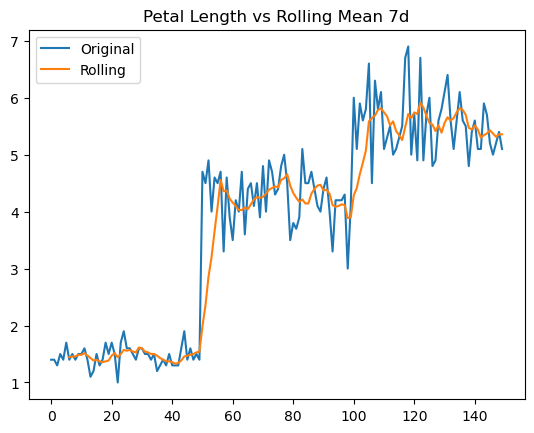

In [26]:
plt.plot(pdf_time['petal length (cm)'])
plt.plot(pdf_time['rolling_petal'])
plt.title('Petal Length vs Rolling Mean 7d')
plt.legend(['Original','Rolling'])

### Explicación
Gráfico comparando serie original y su media móvil suavizada para observar tendencia y reducir ruido en la variable de pétalo.


## 9. Intervalos e interval joins (Polars estilo)

In [32]:
df_vals = pl.DataFrame({'valor': np.random.uniform(0,8,10)})

df_int = pl.DataFrame({
    'left':[0,2,4,6],
    'right':[2,4,6,8],
    'categoria':['baja','media','alta','max']
})

result = (
    df_vals.lazy()
    .join(
        df_int.lazy(),
        how="cross"
    )
    .filter(
        (pl.col("valor") >= pl.col("left")) &
        (pl.col("valor") <  pl.col("right"))
    )
    .collect()
)

result

valor,left,right,categoria
f64,i64,i64,str
1.373096,0,2,"""baja"""
1.982711,0,2,"""baja"""
2.106506,2,4,"""media"""
2.239338,2,4,"""media"""
4.270445,4,6,"""alta"""
4.946824,4,6,"""alta"""
5.529486,4,6,"""alta"""
7.34264,6,8,"""max"""
7.410809,6,8,"""max"""


### Explicación
Simulación de interval join: se genera tabla de intervalos (`left`, `right`) y se hace un `join` condicional (`predicate='<=')`. Polars permite condiciones en joins para emparejamientos más flexibles.


## 10. Optimización de tipos en Polars

In [30]:
df_opt = df.with_columns([
    pl.col('target').cast(pl.Categorical)
])
df_opt.dtypes

[Float64, Float64, Float64, Float64, Categorical]

### Explicación
Conversión de `target` a categoría (`pl.Categorical`) optimiza memoria y puede acelerar agrupaciones y comparaciones en Polars.
